In [1]:
from pathlib import Path
import numpy as np

def load_scanned_object(name):
    E_shift = 2
    if name == "matka_boska":
        e_xy = np.load(Path("data/objects/Matka_Boska/Matka_Boska_data_corr_total_Cu.npz"), allow_pickle=True)["E_xy"]
        peaks = [720, 985, 1594, 2068]
        peak_energies = [3.692, 5.088, 8.046, 10.551]    
    if name == "pigment_palette":
        e_xy = np.load(Path("data/objects/pigment_palette/GEM_Cr_PBS1_PadsPalette_ArCO2_80_20_Gain_35_Thr_35_HV3490_Xray_50kV_1mA_Pinhol_2mm_sum_3-23_GainCorr_Fe.npz"), allow_pickle=True)["E_xy"].astype(float) / (1 << E_shift)

        e_xy= np.fliplr(np.rot90(e_xy, k=1))
        peaks = None
        peak_energies = None
    else:
        raise ValueError(f"Unknown object name: {name}")

    return e_xy, peaks, peak_energies

pad_names = [
    "mn_fe",          # Umbra
    "ca_zn",          # Żółta neapolitańska ???
    "s_as_ca_zn",     # Aurypigment
    "ca_zn_pb",       # Żółta neapolitańska ???
    "mn",             # Fiolet manganowy
    
    "s_hg",           # Umbra
    "wood",           # Deska (Drewno)
    "cr",             # Zieleń chromowa
    "ti",             # Biel tytanowa
    "s_as",           # Realgar (Madryt)

    "si_zr",          # Ceruleum
    "fe",             # Raw Siena
    "na_al_si_s",     # Ultramaryna
    "s_k_cd",         # Żółta kadmowa
    "si_k_co",        # Smalta

    "sn_pb",          # Żółta cynowo-ołowiowa
    "cu",             # Malachit
    "pb",             # Minia ołowiowa
    "ag",             # Srebro
    "al",             # Aluminium

    "s_zn",           # Biel cynkowa
    "co",             # Niebieski kobaltowy
    "s_ba",           # Biel barytowa
    "s_au",           # Złoto
    "cu_zn"           # Mosiądz
]

def filtered_element_name(pad_name, excluded_elements):
    return "_".join([name for name in pad_name.split("_") if name not in excluded_elements])

def generate_bounding_boxes(pads):
    grid_size = (5, 5)
    box_size = (16, 16)
    offset = (9, 9)
    spacing = (6, 6)

    positions = {}
    rows, cols = grid_size
    box_h, box_w = box_size
    x_offset, y_offset = offset
    x_spacing, y_spacing = spacing

    count = 1
    for i in range(rows):
        for j in range(cols):
            x1 = x_offset + i * (box_h + x_spacing)
            x2 = x1 + box_h
            y1 = y_offset + j * (box_w + y_spacing)
            y2 = y1 + box_w
            positions[pads[i*cols + j]] = (x1, x2, y1, y2)
            count += 1
    
    return positions

excluded_elements = {"al", "ag", "s", "si", "na"}
pad_names = [filtered_element_name(name, excluded_elements) for name in pad_names ]
pad_positions = generate_bounding_boxes(pad_names)

def average_patches(e_xy, patch_size = 1):
    if patch_size == 1:
        return e_xy
    A = patch_size
    X, Y, C = e_xy.shape

    X_trim = X - (X % A)
    Y_trim = Y - (Y % A)
    e_xy = e_xy[:X_trim, :Y_trim, :]

    X_prime = X_trim // A
    Y_prime = Y_trim // A
    e_xy_patched = e_xy.reshape(X_prime, A, Y_prime, A, C)
    averaged = e_xy_patched.mean(axis=(1, 3))

    return averaged  # shape will be (X//A, Y//A, C)

In [2]:
object_name = "pigment_palette"
patch_size = 1 

e_xy, peaks, peak_energies = load_scanned_object(object_name)
# e_xy = average_patches(e_xy, patch_size)

In [3]:
from src.DataPreprocessor import DataPreprocessor
import numpy as np
from skimage.filters import gaussian

def apply_smoothing_and_padding(e_xy, padding_size=196, spatial_padding=False):
    result = e_xy
    if spatial_padding:
        result = gaussian(result, sigma=0.6)
    result = np.apply_along_axis(
        gaussian, axis=2, arr=result, sigma=64, preserve_range=True
    )
    
    result[:, :, :padding_size] = 0
    result[:, :, -padding_size:] = 0
    
    max_norm_coeff = np.max(result, axis=2, keepdims=True)
    result /= max_norm_coeff

    return result 

# e_xy_smooth = apply_smoothing_and_padding(e_xy, spatial_padding=True)

/tmp/ipykernel_236844/665309315.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


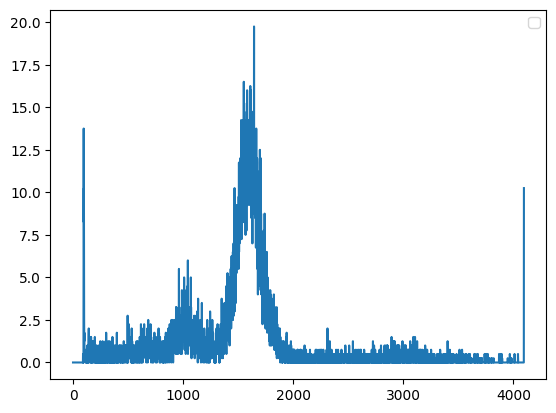

In [4]:
import matplotlib.pyplot as plt
import random 
aa = np.copy(e_xy[20, 40])
plt.plot(e_xy[20, 40])
plt.legend()

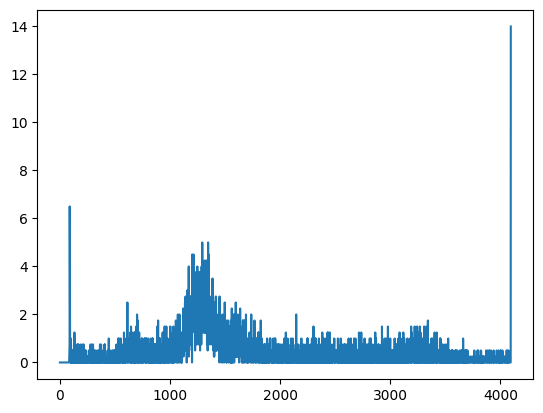

In [5]:
plt.plot(e_xy[20, 20])

In [6]:
from tqdm import tqdm
if object_name == "pigment_palette":
    e_xy_processed = e_xy 
    for pad_name, (x1, x2, y1, y2) in tqdm(pad_positions.items()):
        plt.figure(random.randint(1, int(10e10)))
        if pad_name in ["", "mn_fe", "cu_zn", "as_ca_zn", "ca_zn_pb", "sn_pb"]:
            continue
        AAAAAA = np.load(Path("data/objects/pigment_palette/1_calibrated_spectra.npz"), allow_pickle=True)[pad_name]
        peaks = np.load(Path("data/objects/pigment_palette/1_calibrated_spectra.npz"), allow_pickle=True)[f"{pad_name}_peaks"]
        peak_energies = np.load(Path("data/objects/pigment_palette/1_calibrated_spectra.npz"), allow_pickle=True)[f"{pad_name}_energies"]
        energy_range, temp = DataPreprocessor.processed_spectra(e_xy[x1:x2, y1:y2], peaks, peak_energies, discrete_transformation=True)
        e_xy[x1:x2, y1:y2] = temp.astype("float")
H, W, C = e_xy.shape

 48%|████▊     | 11/23 [00:00<00:00, 107.30it/s]/tmp/ipykernel_236844/4173668738.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(random.randint(1, int(10e10)))
100%|██████████| 23/23 [00:00<00:00, 95.49it/s] 


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def plot_pad_max_peak_positions(e_xy, object_name):
    peak_map = np.argmax(e_xy, axis=2)



    _, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(peak_map, cmap="viridis")
    cbar = plt.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label("Max peak position")
    for pad_name, (x1, x2, y1, y2) in  pad_positions.items():
        width, height = y2 - y1, x2 - x1
        rect = patches.Rectangle((y1, x1), width, height, linewidth=1.5, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
    plt.title("Max Peak Positions")
    plt.xlabel("X position")
    plt.ylabel("Y position")
    
    plt.savefig(f"data/plots/max_peak_positions{object_name}.svg", bbox_inches='tight',  pad_inches=0)

def plot_pad_photon_counts(e_xy, object_name): 
    photon_count_map = np.sum(e_xy, axis=2)
    photon_count_map /= np.max(photon_count_map)

    _, ax = plt.subplots(figsize=(8, 8))
    plt.title("Relative Photon Counts")
    plt.xlabel("X position")
    plt.ylabel("Y position")
    im = ax.imshow(photon_count_map, cmap="viridis")
    cbar = plt.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label("Relative photon counts")
    
    plt.savefig(f"data/plots/photon_counts{object_name}.svg", bbox_inches='tight',  pad_inches=0)

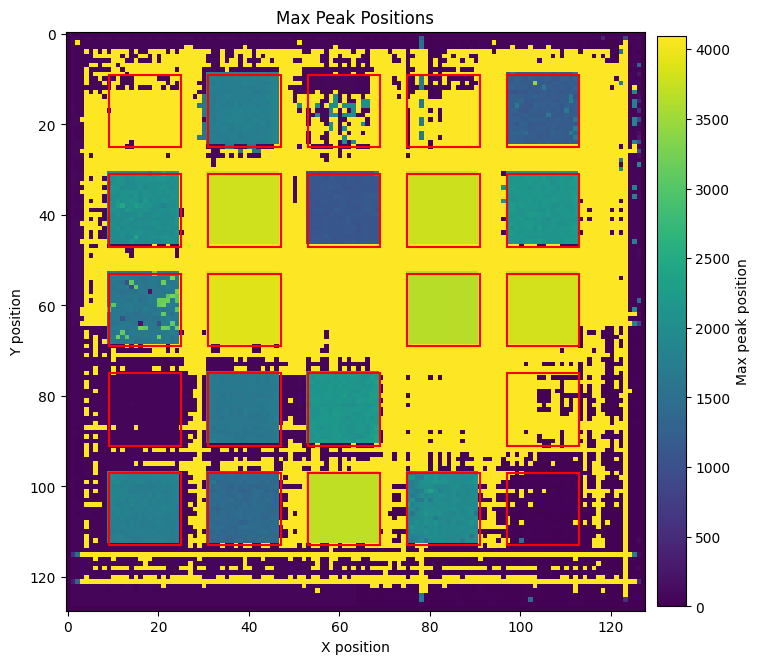

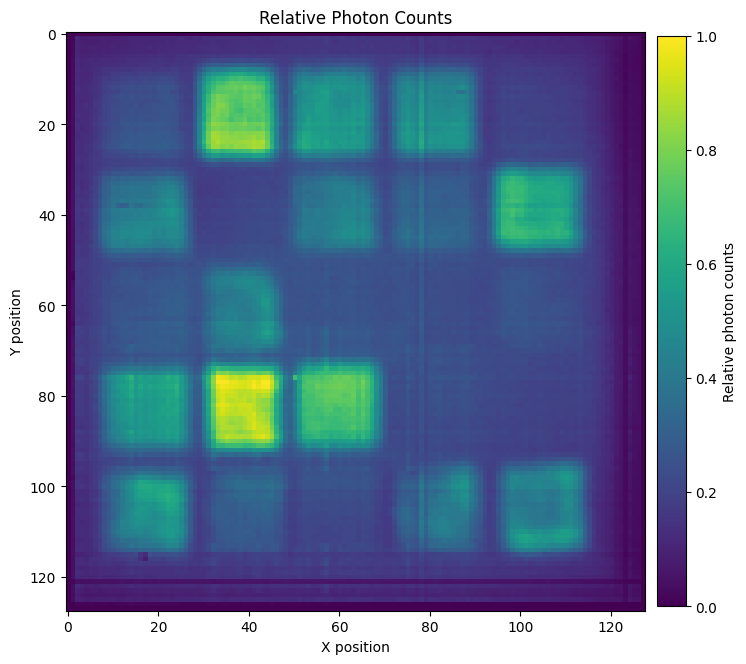

In [8]:
plot_pad_max_peak_positions(e_xy, object_name)
plot_pad_photon_counts(e_xy, object_name)

4720.75
4637.0


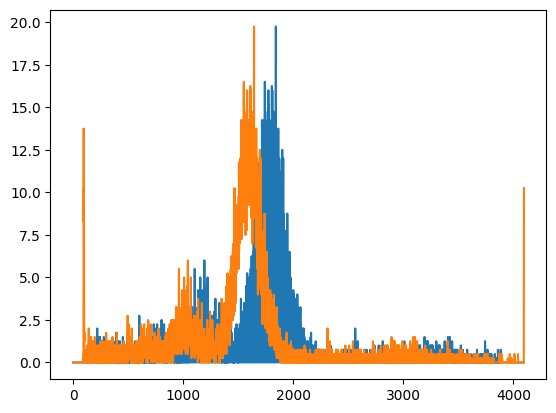

In [11]:
plt.plot(e_xy[20, 40], label="20, 20")
plt.plot(aa)
print(np.sum(aa))
print(np.sum(e_xy[20, 40]))

In [10]:
result = {"e_xy": e_xy_smooth, "peaks": peaks, "peak_energies": peak_energies }
np.savez(
    f"data/objects/processed/{object_name}_{patch_size}x{patch_size}_patches.npz", **result
)

NameError: name 'e_xy_smooth' is not defined